# DECARBONIZATION - EXAMPLE I
---

In [18]:
import pypsa
import pandas as pd
import numpy as np

# Βήμα 1: Αρχικοποίηση του δικτύου
network_old = pypsa.Network()

# Βήμα 2: Ορισμός χρονικού πλαισίου (24 ώρες)
snapshots = pd.date_range("2026-01-01 00:00", "2026-01-01 23:00", freq="h")
network_old.set_snapshots(snapshots)

# Βήμα 3: Δημιουργία κεντρικού διαύλου (Bus)
network_old.add("Bus", "Main Bus")

# Βήμα 4: Προσθήκη συμβατικών μονάδων παραγωγής
# Μονάδα Άνθρακα (Coal)
network_old.add("Generator", "Coal Plant",
                bus="Main Bus",
                p_nom=200,          # Ονομαστική ισχύς σε MW
                marginal_cost=220,   # Κόστος ανά MWh
                carrier="coal")

# Μονάδα Φυσικού Αερίου (Gas)
network_old.add("Generator", "Gas Plant",
                bus="Main Bus",
                p_nom=150,          # Ονομαστική ισχύς σε MW
                marginal_cost=200,   # Κόστος ανά MWh (φθηνότερο από άνθρακα)
                carrier="gas")

# Βήμα 5: Ορισμός προφίλ φορτίου (Ενδεικτική ωριαία ζήτηση)
# Δημιουργούμε μια τυχαία διακύμανση ζήτησης για το παράδειγμα *****************************
hourly_load = [ 180, 170, 165, 160, 160, 165, 170, 180, 190, 200,  
                210, 220, 230, 240, 245, 250, 245, 240, 230, 220,
                210, 200, 190, 185]

network_old.add("Load", "Baseline Load", 
                bus="Main Bus", 
                p_set=hourly_load)

# Βήμα 6: Βελτιστοποίηση δικτύου
# Χρησιμοποιεί Linear Optimal Power Flow (LOPF)
network_old.optimize(solver_name='highs') # Απαιτείται solver όπως glpk ή gurobi

# Βήμα 7: Εξαγωγή αποτελεσμάτων
initial_system_cost = network_old.objective
print(f"Initial System Costs: {initial_system_cost}")


# total_cost = network_old.objective
# print(f"Συνολικό Λειτουργικό Κόστος (OPEX): {total_cost:.2f} $")

# # Προαιρετικά: Εμφάνιση παραγωγής ανά μονάδα
# print("\nΠαραγωγή ανά ώρα (MW):")
# print(network_old.generators_t.p)

Index(['Main Bus'], dtype='str', name='name')
Index(['Coal Plant', 'Gas Plant'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 48 primals, 120 duals
Objective: 9.96e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


Initial System Costs: 996100.0


In [36]:
import pypsa
import pandas as pd

# Βήμα 1:  Αρχικοποίηση και Snapshot (24 ώρες)
network_new = pypsa.Network()

# Βήμα 2: Snapshot (24 ώρες)
snapshots = pd.date_range("2026-01-01 00:00", "2026-01-01 23:00", freq="h")
network_new.set_snapshots(snapshots)

# Βήμα 3: Κεντρικός Δίαυλος
network_new.add("Bus", "Main Bus")

# Βήμα 4: Προφίλ Διαθεσιμότητας (0.0 έως 1.0)
# Παράδειγμα: Ηλιακή παραγωγή που κορυφώνεται το μεσημέρι
solar_availability = [0, 0, 0, 0, 0, 0, 0.1, 0.2, 0.4, 0.6, 0.8, 
                      0.9, 1.0, 0.9, 0.8, 0.6, 0.4, 0.2, 0.1, 0,
                      0, 0, 0, 0] 
                      
# Παράδειγμα: Αιολική παραγωγή με μικρές διακυμάνσεις
wind_availability = [0.6, 0.7, 0.8, 0.6, 0.5, 0.4, 0.6, 0.7, 0.8,
                     0.7, 0.6, 0.5, 0.4, 0.5, 0.6, 0.7, 0.8, 0.7,
                     0.6, 0.5, 0.4, 0.5, 0.6, 0.7] 

# Βήμα 5: Προσθήκη Γεννητριών
# Backup Gas: Σταθερή ισχύς, υψηλό λειτουργικό κόστος
network_new.add("Generator", "Gas Plant",
                bus="Main Bus",
                p_nom=150,
                marginal_cost=400,  #*********************************
                carrier="gas") # Υψηλό κόστος για να αποφεύγεται η χρήση του

# Solar PV: Επεκτάσιμο (p_nom_extendable=True)
network_new.add("Generator", "Solar PV",
                bus="Main Bus",
                p_nom_extendable=True, # *********************************** Το PyPSA θα βρει το βέλτιστο μέγεθος
                #p_nom_max = 184,      # ****************************
                capital_cost=600,      # Κόστος επένδυσης ανά MW
                marginal_cost=0,       # Δωρεάν λειτουργία (ήλιος)
                p_max_pu=solar_availability,
                carrier="solar")

# Onshore Wind: Σταθερή ισχύς
network_new.add("Generator", "Onshore Wind",
                bus="Main Bus",
                p_nom = 150,
                capital_cost=800,
                marginal_cost=0,
                p_max_pu=wind_availability,
                carrier = "wind")

# Βήμα 6: Φορτίο (ίδιο με το baseline)
hourly_load = [180, 170, 165, 160, 160, 165, 170, 180, 190, 200,
               210, 220, 230, 240, 245, 250, 245, 240, 230, 220,
               210, 200, 190, 185]

network_new.add("Load", "Baseline Load", bus="Main Bus", p_set=hourly_load)

# Βήμα 7: Βελτιστοποίηση (CAPEX + OPEX)
network_new.optimize(solver_name='highs')

# Βήμα 8: Ανάλυση Αποτελεσμάτων
total_system_cost = network_new.objective
optimized_solar_capacity = network_new.generators.at["Solar PV", "p_nom_opt"]

print(f"Συνολικό Κόστος Συστήματος (OPEX+CAPEX): {total_system_cost:.2f} $")
print(f"Βέλτιστη Εγκατεστημένη Ισχύς Φωτοβολταϊκών: {optimized_solar_capacity:.2f} MW")

Index(['Main Bus'], dtype='str', name='name')
Index(['Gas Plant', 'Solar PV', 'Onshore Wind'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.14s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 73 primals, 169 duals
Objective: 6.94e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


Συνολικό Κόστος Συστήματος (OPEX+CAPEX): 694333.33 $
Βέλτιστη Εγκατεστημένη Ισχύς Φωτοβολταϊκών: 241.67 MW


---
# ΓΡΑΦΗΜΑΤΑ ΒΑΣΙΚΟΥ ΜΟΝΤΕΛΟΥ ΚΑΙ ΑΝΑΝΕΩΜΈΝΟΥ ΜΟΝΤΈΛΟΥ 

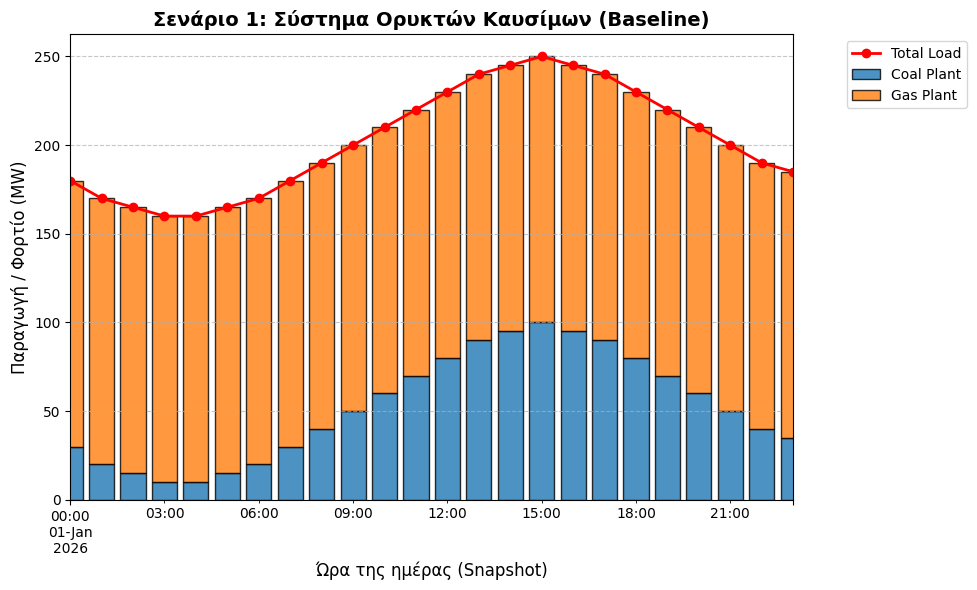

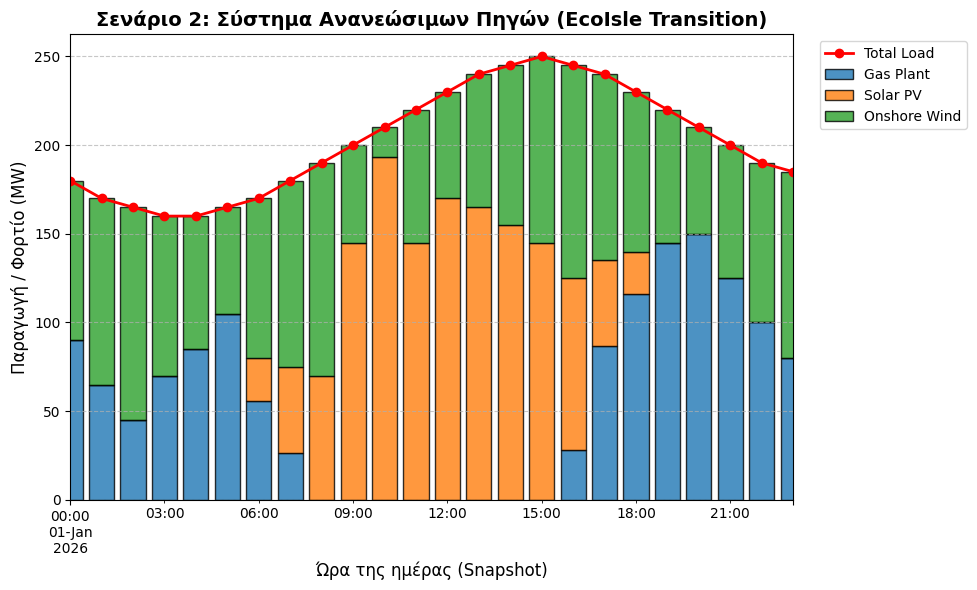

In [37]:
import matplotlib.pyplot as plt

def plot_generation_dispatch(network, title):
    # Εξαγωγή των δεδομένων παραγωγής (Dispatch) ανά ώρα
    # Το .p είναι η ισχύς που παρήγαγε κάθε γεννήτρια
    dispatch = network.generators_t.p
    
    # Δημιουργία του γραφήματος
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Σχεδίαση σωρευτικών ράβδων (stacked bar)
    dispatch.plot(kind="bar", stacked=True, ax=ax, width=0.8, edgecolor='black', alpha=0.8)
    
    # Προσθήκη της γραμμής του συνολικού φορτίου (Load) για έλεγχο
    load = network.loads_t.p_set.sum(axis=1)
    load.plot(kind="line", marker='o', color='red', ax=ax, label='Total Load', linewidth=2)
    
    # Ρυθμίσεις εμφάνισης
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Ώρα της ημέρας (Snapshot)", fontsize=12)
    ax.set_ylabel("Παραγωγή / Φορτίο (MW)", fontsize=12)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Βήμα 3: Σχεδίαση για το παραδοσιακό σύστημα (Fossil-based)
if 'network_old' in locals():
    plot_generation_dispatch(network_old, "Σενάριο 1: Σύστημα Ορυκτών Καυσίμων (Baseline)")

# Βήμα 4: Σχεδίαση για το σύστημα ΑΠΕ (Renewable-based)
if 'network_new' in locals():
    plot_generation_dispatch(network_new, "Σενάριο 2: Σύστημα Ανανεώσιμων Πηγών (EcoIsle Transition)")

---
# Συγκριτική Ανάλυση Κόστους

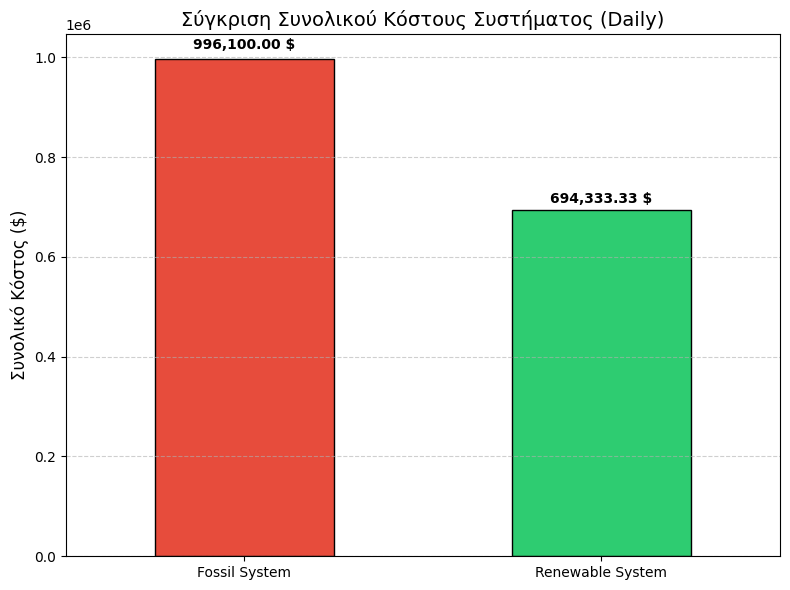

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# Υποθέτουμε ότι network_old και network_new έχουν βελτιστοποιηθεί επιτυχώς
# Εξαγωγή κόστους
costs = {
    "Fossil System": network_old.objective,
    "Renewable System": network_new.objective
}

# Μετατροπή σε DataFrame για ευκολότερη διαχείριση
df_costs = pd.Series(costs)

# Δημιουργία γραφήματος σύγκρισης
plt.figure(figsize=(8, 6))
df_costs.plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')

plt.title("Σύγκριση Συνολικού Κόστους Συστήματος (Daily)", fontsize=14)
plt.ylabel("Συνολικό Κόστος ($)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Προσθήκη ετικετών με τις τιμές πάνω από τις μπάρες
for i, v in enumerate(df_costs):
    plt.text(i, v + (v * 0.02), f"{v:,.2f} $", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
# Υπολογισμός και Διαχωρισμός Κόστους

In [39]:
# Step 01: Compare total system costs
print(f"Old Fossil System Cost (OPEX only): "
      f"{network_old.objective:.2f}")
print(f"New Renewable System Cost (OPEX + CAPEX): "
      f"{network_new.objective:.2f}")

# Step 02: Calculate OPEX-only for the renewable system
renewable_opex = (network_new.generators_t.p * network_new.generators.marginal_cost).sum().sum()
print(f"New Renewable System OPEX only: "
      f"{renewable_opex:.2f}")

Old Fossil System Cost (OPEX only): 996100.00
New Renewable System Cost (OPEX + CAPEX): 694333.33
New Renewable System OPEX only: 549333.33


In [40]:
# Βήμα 1: Συνολικό κόστος (CAPEX + OPEX) από το optimization objective
total_cost_renewable = network_new.objective
total_cost_fossil = network_old.objective # Εδώ είναι μόνο OPEX

# Βήμα 2: Απομόνωση του OPEX για το ανανεώσιμο σύστημα
# Πολλαπλασιάζουμε την ωριαία παραγωγή (p) με το οριακό κόστος (marginal_cost)
generators_p = network_new.generators_t.p
marginal_costs = network_new.generators.marginal_cost

# Υπολογισμός OPEX ανά γεννήτρια και άθροιση
opex_per_generator = generators_p.multiply(marginal_costs, axis=1).sum()
total_opex_renewable = opex_per_generator.sum()

# Βήμα 3: Υπολογισμός CAPEX (Επένδυση)
# Το CAPEX είναι η διαφορά: Συνολικό Κόστος - OPEX
total_capex_renewable = total_cost_renewable - total_opex_renewable

print(f"--- Fossil System (Baseline) ---")
print(f"Total OPEX: {total_cost_fossil:,.2f} units")

print(f"\n--- Renewable System (EcoIsle) ---")
print(f"Total OPEX: {total_opex_renewable:,.2f} units")
print(f"Total CAPEX (Investment): {total_capex_renewable:,.2f} units")
print(f"TOTAL OBJECTIVE (OPEX+CAPEX): {total_cost_renewable:,.2f} units")

--- Fossil System (Baseline) ---
Total OPEX: 996,100.00 units

--- Renewable System (EcoIsle) ---
Total OPEX: 549,333.33 units
Total CAPEX (Investment): 145,000.00 units
TOTAL OBJECTIVE (OPEX+CAPEX): 694,333.33 units


## ΥΠΟΛΟΓΙΣΜΟΣ ΤΩΝ ΕΚΠΟΜΠΩΝ CO2​

In [41]:
# Step 01: Define emission factors
# (example values in tons of CO2 per MWh)
emission_factors = {
    "Coal Plant": 0.9,    # High emissions for coal
    "Gas Plant": 0.4,     # Moderate emissions for gas
    "Solar PV": 0,        # Zero emissions for solar
    "Onshore Wind": 0     # Zero emissions for wind
}

# Step 02: Assign emission factors to generators
for gen_name, ef in emission_factors.items():
    if gen_name in network_old.generators.index:
        network_old.generators.loc[gen_name, 
                                 'emission_factor'] = ef
    if gen_name in network_new.generators.index:
        network_new.generators.loc[gen_name, 
                                 'emission_factor'] = ef

# Step 03: Define function to calculate total emissions
def calculate_total_emissions(network):
    emissions = 0
    for gen_name, gen_data in network.generators.iterrows():
        generation = network.generators_t.p[gen_name]
        emission_factor = gen_data['emission_factor']
        gen_emissions = sum(generation * emission_factor)
        emissions += gen_emissions
    return emissions

# Step 04: Calculate emissions for both systems
old_emissions = calculate_total_emissions(network_old)
new_emissions = calculate_total_emissions(network_new)

# Step 05: Output emissions results
print(f"Old System Emissions: {old_emissions} tons CO2")
print(f"New System Emissions: {new_emissions} tons CO2")

Old System Emissions: 2569.5 tons CO2
New System Emissions: 549.3333333333333 tons CO2



### Προτεινόμενα Πειράματα για Βαθύτερη Ανάλυση

#### 1. Σταθερή Ισχύς Φωτοβολταϊκών (Χωρίς Βελτιστοποίηση)
- Η Δοκιμή: Θέτουμε **p_nom_extendable=False** και ορίζουμε μια τυχαία ισχύ (π.χ. 100 MW).
-Στόχος: Να δούμε πόσο "χειρότερο" (ακριβότερο) είναι ένα σύστημα που σχεδιάστηκε με το μάτι, σε σύγκριση με το βελτιστοποιημένο σύστημα που πρότεινε το PyPSA.

#### 2. Περιορισμοί στις Επενδύσεις
-Η Δοκιμή: Χρήση της παραμέτρου **p_nom_max** για να θέσουμε ένα ανώτατο όριο στα φωτοβολταϊκά (π.χ. λόγω έλλειψης χώρου στο νησί).
-Στόχος: Να κατανοήσουμε πώς οι χωροταξικοί ή οικονομικοί περιορισμοί αυξάνουν την ανάγκη για ορυκτά καύσιμα.

#### 3. Αύξηση του Κόστους του Αερίου (Carbon Pricing)
-Η Δοκιμή: Διπλασιασμός του **marginal_cost** της μονάδας αερίου.
-Στόχος: Προσομοίωση της αστάθειας των τιμών των καυσίμων ή της επιβολής φόρου άνθρακα. Θα παρατηρήσετε ότι το μοντέλο θα "πιέσει" για ακόμα περισσότερες ΑΠΕ.

##### 4. Αλλαγή στα Καιρικά Προφίλ
-Η Δοκιμή: Τροποποίηση των **solar_profile** και **wind_profile** (π.χ. μια συννεφιασμένη μέρα ή μια μέρα χωρίς άνεμο).
-Στόχος: Έλεγχος της ανθεκτικότητας (resilience) του συστήματος. Τι συμβαίνει στο κόστος όταν οι δωρεάν πόροι μειώνονται;

##### 5. Αύξηση της Ζήτησης (Load Scaling)
-Η Δοκιμή: Πολλαπλασιασμός του **hourly_load** επί 1.5 (αύξηση 50%).
-Στόχος: Μελέτη της μελλοντικής ανάπτυξης του νησιού (π.χ. λόγω ηλεκτροκίνησης). Θα επαρκούν οι υπάρχουσες υποδομές;